In [370]:
import numpy as np 
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer, SimpleImputer


import numpy as np
from sklearn.linear_model import Lasso, Ridge
import plotly.express as px
from matplotlib.widgets import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor


from sklearn.model_selection import GridSearchCV
import numpy as np
from flask import Flask, request, render_template
from waitress import serve

import pickle





from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
pd.set_option('display.max_columns', None)  #Gjør sånn at hele tabellen vises:)


##Spørsmåol til gruppelder
# Skal man fjerne uteliggere på hele df?
# Hvilke visulaisering skal gjøres på df




# Datemodellering

In [371]:
df = pd.read_csv("vasket_data.csv")
df

,pasient_id,antall_komorbiditeter,koma_score,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,sykdom_underkategori_ARF/MOSF w/Sepsis,sykdom_underkategori_CHF,sykdom_underkategori_COPD,sykdom_underkategori_Cirrhosis,sykdom_underkategori_Colon Cancer,sykdom_underkategori_Coma,sykdom_underkategori_Lung Cancer,sykdom_underkategori_MOSF w/Malig,kreft_metastatic,kreft_no,kreft_yes,alder,utdanning,inntekt,kjønn_female,kjønn_male,etnisitet_asian,etnisitet_black,etnisitet_hispanic,etnisitet_other,etnisitet_white,etnisitet_nan,sykehusdød,oppholdslengde,blodtrykk,hvite_blodlegemer,hjertefrekvens,respirasjonsfrekvens,kroppstemperatur,lungefunksjon,serumalbumin,kreatinin,natrium,blod_ph,glukose,blodurea_nitrogen,urinmengde,adl
0,2.0,2.0,44.0,52.695312,74.0,0.001000,0.000000,0.0,0.0,0.00,0.000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,60.33899,12.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,43.0,17.097656,112.0,34.0,34.59375,98.00000,3.500000,5.500000,132.0,7.250000,NaN,6.51,2502.0,1.0
1,3.0,2.0,0.0,20.500000,45.0,0.790894,0.664917,0.0,0.0,0.75,0.500,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,52.74698,12.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.0,70.0,8.500000,88.0,28.0,37.39844,231.65625,3.500000,2.000000,134.0,7.459961,NaN,6.51,2502.0,1.0
2,4.0,2.0,0.0,20.097656,19.0,0.698975,0.411987,0.0,0.0,0.90,0.500,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,42.38498,11.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,75.0,9.099609,88.0,32.0,35.00000,333.30000,3.500000,0.799927,139.0,NaN,NaN,6.51,2502.0,0.0
3,6.0,1.0,55.0,19.398438,27.0,0.284973,0.214996,0.0,0.0,0.00,0.000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,93.01599,14.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,110.0,10.398438,101.0,44.0,38.39844,266.62500,3.500000,0.699951,140.0,7.659180,NaN,6.51,2502.0,1.0
4,7.0,1.0,0.0,17.296875,46.0,0.892944,0.820923,0.0,0.0,NaN,0.700,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,62.37097,14.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9.0,78.0,11.699219,120.0,28.0,37.39844,309.50000,4.799805,1.599854,132.0,7.479492,NaN,6.51,2502.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7724,9101.0,1.0,0.0,16.296875,22.0,0.852905,0.801880,0.0,0.0,0.80,0.512,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,66.07300,8.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,23.0,109.0,7.399414,104.0,22.0,35.69531,280.00000,3.699707,1.099854,131.0,7.459961,188.0,21.00,2502.0,0.0
7725,9102.0,1.0,41.0,25.796875,31.0,0.553955,0.485962,0.0,0.0,0.50,0.500,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,55.15399,11.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29.0,43.0,9.000000,0.0,8.0,38.59375,218.50000,3.500000,5.899414,135.0,7.289062,190.0,49.00,0.0,0.0
7726,9103.0,1.0,0.0,22.699219,39.0,0.741943,0.660889,0.0,0.0,0.90,0.800,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,70.38196,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,111.0,8.398438,83.0,24.0,36.69531,180.00000,3.500000,2.699707,139.0,7.379883,189.0,60.00,3900.0,NaN
7727,9104.0,1.0,0.0,40.195312,51.0,0.177979,0.091995,0.0,0.0,0.09,0.090,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,47.01999,13.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,7.0,99.0,7.599609,110.0,24.0,36.39844,428.56250,1.199951,3.500000,135.0,7.469727,246.0,55.00,2502.0,0.0


In [372]:





# Legger til en ny kolonne som inneholder gjennomsnittet av de to estimatene
df["gjennomsnitt_overlevelsesestimat_2mnd"] = df[["lege_overlevelsesestimat_2mnd", "overlevelsesestimat_2mnd"]].mean(axis=1)

df["gjennomsnitt_overlevelsesestimat_2mnd"] = df[["lege_overlevelsesestimat_2mnd", "overlevelsesestimat_2mnd"]].mean(axis=1)

#Gjennomsnitt av overlevelsesestimat og lege overlevelsesestimat


## Deler opp i treningsdata, testdata og valideringsdata

In [373]:
X = df.drop(columns=['oppholdslengde']) #feature
y = df['oppholdslengde'] #target-sett

#trenings og midlertidig sett
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# deler det midlertidige settet i validering og test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

#Linear regression, randomforest, ridge, RandomForestRegressor, KNeighborsClassifier, PolynomialFeatures

## Fjerning av uteligger

Jeg ser på boksplottet for å vurdere om det er nødvendig å fjerne uteliggere, og for å få en oversikt over hvor mange og hvor ekstreme disse uteliggerne er i datasettet.

Kom til rap: jeg så først overordnet på alle og bestemte meg for de som påvirket modellen mest på en positivt måte. 

### Urinmengde

In [374]:
fig = px.box(X_train['urinmengde'], title = ('Boxplot for urinmengde'))
fig.update_layout(xaxis_title='urinmengde', yaxis_title='Verdi')
fig.show()

Jeg klipper verdiene i urinmengde ved 25. og 75. prosentilen for å redusere påvirkningen av ekstreme verdier, som kan gi en mer bedre analyse og hindre skjevfordeling i dataene

In [375]:

q75_urinmengde = X_train["urinmengde"].quantile(0.75)
X_train["urinmengde"] = X_train["urinmengde"].clip(upper=q75_urinmengde)
q25_urinmengde = X_train["urinmengde"].quantile(0.25)
X_train["urinmengde"] = X_train["urinmengde"].clip(lower=q25_urinmengde)


### Kreatinin og hvite blodlegemer

In [376]:
fig_kreatinin = px.box(X_train['kreatinin'], title = ('Boxplot for kreatinin'))
fig_kreatinin.update_layout(xaxis_title='kreatinin', yaxis_title='Verdi')
fig_kreatinin.show()

fig_hvite_blodlegemer= px.box(X_train['hvite_blodlegemer'], title = ('Boxplot for hvite blodlegemer'))
fig_hvite_blodlegemer.update_layout(xaxis_title='hvite_blodlegemer', yaxis_title='Verdi')
fig_hvite_blodlegemer.show()

Jeg klipper verdiene i urinmengde ved 95. prosentilen for å redusere påvirkningen av ekstreme verdier, som kan gi en mer bedre analyse og hindre skjevfordeling i dataene

In [377]:

q95_kreatinin = X_train["kreatinin"].quantile(0.95)
X_train["kreatinin"] = X_train["kreatinin"].clip(upper=q95_kreatinin)

q95_hvite_blodlegemer = X_train["hvite_blodlegemer"].quantile(0.95)
X_train["hvite_blodlegemer"] = X_train["hvite_blodlegemer"].clip(upper=q95_hvite_blodlegemer)



### Blodurea nitrogen og glukose

In [378]:
fig_blodurea_nitrogen = px.box(X_train['blodurea_nitrogen'], title = ('Boxplot for blodurea nitrogen'))
fig_blodurea_nitrogen.update_layout(xaxis_title='Blodurea nitrogen', yaxis_title='Verdi')
fig_blodurea_nitrogen.show()

fig_glukose= px.box(X_train['glukose'], title = ('Boxplot for glukose'))
fig_glukose.update_layout(xaxis_title='glukose', yaxis_title='Verdi')
fig_glukose.show()

Jeg klipper verdiene i urinmengde ved 75. prosentilen for å redusere påvirkningen av ekstreme verdier, som kan gi en mer bedre analyse og hindre skjevfordeling i dataene

In [379]:

q95_blodurea_nitrogen = X_train["blodurea_nitrogen"].quantile(0.75)
X_train["blodurea_nitrogen"] = X_train["blodurea_nitrogen"].clip(upper=q95_blodurea_nitrogen)

q95_glukose = X_train["glukose"].quantile(0.75)
X_train["glukose"] = X_train["glukose"].clip(upper=q95_glukose)

## Variabelutvinning

## Imputering av manglende data

In [380]:
print(df.isnull().sum())

imputation_strategies = {
    "mean_imputer": SimpleImputer(strategy='mean'),
    "knn_imputer 50": KNNImputer(n_neighbors=50),
    "knn_imputer 10": KNNImputer(n_neighbors=10),
    "knn_imputer 100": KNNImputer(n_neighbors=100),
    "knn_imputer 150": KNNImputer(n_neighbors=150),
    "median_imputer": SimpleImputer(strategy='median'),
    "most_frequent_imputer": SimpleImputer(strategy='most_frequent')
}

for key, strategy in imputation_strategies.items(): 
    strategy.fit(X_train)

filled_X_train = {key : strategy.transform(X_train) for key, strategy in imputation_strategies.items() }
filled_x_val = {key : strategy.transform(X_val) for key, strategy in imputation_strategies.items() }

pasient_id                                   0
antall_komorbiditeter                        0
koma_score                                   0
fysiologisk_score                            0
apache_fysiologisk_score                     0
overlevelsesestimat_2mnd                     0
overlevelsesestimat_6mnd                     0
diabetes                                     0
demens                                       0
lege_overlevelsesestimat_2mnd             1417
lege_overlevelsesestimat_6mnd             1403
sykdom_underkategori_ARF/MOSF w/Sepsis       0
sykdom_underkategori_CHF                     0
sykdom_underkategori_COPD                    0
sykdom_underkategori_Cirrhosis               0
sykdom_underkategori_Colon Cancer            0
sykdom_underkategori_Coma                    0
sykdom_underkategori_Lung Cancer             0
sykdom_underkategori_MOSF w/Malig            0
kreft_metastatic                             0
kreft_no                                     0
kreft_yes    

## Feature Enigneering

In [381]:

# X_train.drop(['inntekt', 'sykdom_underkategori_CHF', 'diabetes', 'etnisitet_nan', 'sykdom_underkategori_Colon Cancer', 'etnisitet_asian', 'kjønn_male', 'etnisitet_white'], axis=1, inplace=True)
# X_val.drop(['inntekt', 'sykdom_underkategori_CHF', 'diabetes', 'etnisitet_nan', 'sykdom_underkategori_Colon Cancer', 'etnisitet_asian', 'kjønn_male', 'etnisitet_white'], axis=1, inplace=True)
# # Definer kolonnene med feature importance lik 0
# zero_importance_features = feature_importance_df[feature_importance_df['Importance'] == 0]['Feature'].tolist()

# # Fjern kolonner med null importance, men ignorer de som ikke finnes i en av DataFrames
# X_train.drop(zero_importance_features, axis=1, inplace=True, errors='ignore')
# X_val.drop(zero_importance_features, axis=1, inplace=True, errors='ignore')


## Baseline

In [382]:

baseline = DummyRegressor(strategy="mean")
# tilpasse modell
baseline.fit(X_train, y_train)
# prediksjon på valideringsdata
prediction = baseline.predict(X_val)
rmse_baseline = (root_mean_squared_error(y_val, prediction))
print(prediction)
rmse_baseline

#Litt lav???

[17.90924214 17.90924214 17.90924214 ... 17.90924214 17.90924214
 17.90924214]


18.683613878347693

## Splitting av data

In [383]:
def alpha_model_test(imputation_strategy, model_class, model_name, alphas=np.arange(0.1, 1, 0.01), random_state=42):
    models = {
        alpha: model_class(alpha=alpha, random_state=random_state).fit(filled_X_train[imputation_strategy], y_train) 
        for alpha in alphas
    }
    
    rmse = {
        alpha: np.sqrt(mean_squared_error(y_val, model.predict(filled_x_val[imputation_strategy])))
        for alpha, model in models.items()
    }
    
    best_alpha = min(rmse, key=rmse.get)
    best_rmse = rmse[best_alpha]
    
    print(f"Model: {model_name}")
    print("Imputation Strategy:", imputation_strategy)
    print("Best Alpha:", best_alpha)
    print("Best RMSE:", best_rmse)

    fig = px.scatter(x=list(rmse.keys()), y=list(rmse.values()), labels={'x': 'Alpha', 'y': 'RMSE'},
                     title=f"RMSE for {model_name} mht. alpha (Imputation: {imputation_strategy})")
    fig.show()
    
    return best_alpha, best_rmse

def print_alpha_stats(model_class, model_name):
    best_alpha = None
    best_strategy = None
    best_rmse = float("inf")
    
    for strategy in imputation_strategies.keys():
        alpha, rmse = alpha_model_test(strategy, model_class, model_name)
        
        if rmse < best_rmse:
            best_alpha = alpha
            best_strategy = strategy
            best_rmse = rmse

    print("\nOverall best results for:", model_name)
    print("Best Imputation Strategy:", best_strategy)
    print("Best Alpha:", best_alpha)
    print("Best RMSE:", best_rmse)
    
    return best_alpha, best_rmse

best_lasso_alpha, best_lasso_rmse = print_alpha_stats(Lasso, "Lasso")
best_ridge_alpha, best_ridge_rmse = print_alpha_stats(Ridge, "Ridge")



Model: Lasso
Imputation Strategy: mean_imputer
Best Alpha: 0.1
Best RMSE: 17.466343563342658


Model: Lasso
Imputation Strategy: knn_imputer 50
Best Alpha: 0.1
Best RMSE: 17.469160733727936


Model: Lasso
Imputation Strategy: knn_imputer 10
Best Alpha: 0.1
Best RMSE: 17.463297368349394


Model: Lasso
Imputation Strategy: knn_imputer 100
Best Alpha: 0.1
Best RMSE: 17.468831296194473


Model: Lasso
Imputation Strategy: knn_imputer 150
Best Alpha: 0.1
Best RMSE: 17.467713515879637


...

Model: Ridge
Imputation Strategy: knn_imputer 100
Best Alpha: 0.19999999999999996
Best RMSE: 17.277183152305987


Model: Ridge
Imputation Strategy: knn_imputer 150
Best Alpha: 0.20999999999999996
Best RMSE: 17.275667555249548


Model: Ridge
Imputation Strategy: median_imputer
Best Alpha: 0.29999999999999993
Best RMSE: 17.241644349278584


Model: Ridge
Imputation Strategy: most_frequent_imputer
Best Alpha: 0.2799999999999999
Best RMSE: 17.244094476539733



Overall best results for: Ridge
Best Imputation Strategy: median_imputer
Best Alpha: 0.29999999999999993
Best RMSE: 17.241644349278584


In [384]:




models = {
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'LinearRegression': LinearRegression(),
    #'MLPRegressor': MLPRegressor(random_state=42), denne fikk veldig dårlig score men den er teste
    'GradientBoosting' : GradientBoostingRegressor(random_state = 42),
}

In [385]:
rmse_scores = {}

for model_name, model in models.items():
    for strategy_name, imputer in imputation_strategies.items():
        X_train_imputed = imputer.fit_transform(X_train)
        X_val_imputed = imputer.transform(X_val)
        model.fit(X_train_imputed, y_train)
        predictions = model.predict(X_val_imputed)
            
        rmse = np.sqrt(mean_squared_error(y_val, predictions))
        print(f"Model: {model_name}, Imputation: {strategy_name}, RMSE: {rmse:.4f}")
        rmse_scores[(model_name, strategy_name)] = rmse

best_combination = min(rmse_scores, key=rmse_scores.get)
best_model_name, best_strategy_name = best_combination
best_rmse = rmse_scores[best_combination]

print(f"\nOverall best result:")
print(f"Best Model: {best_model_name}")
print(f"Best Imputation Strategy: {best_strategy_name}")
print(f"Best RMSE: {best_rmse:.4f}")



Model: RandomForestRegressor, Imputation: mean_imputer, RMSE: 17.6700
Model: RandomForestRegressor, Imputation: knn_imputer 50, RMSE: 17.6416
Model: RandomForestRegressor, Imputation: knn_imputer 10, RMSE: 17.5677
Model: RandomForestRegressor, Imputation: knn_imputer 100, RMSE: 17.6820
Model: RandomForestRegressor, Imputation: knn_imputer 150, RMSE: 17.6046
Model: RandomForestRegressor, Imputation: median_imputer, RMSE: 17.5772
Model: RandomForestRegressor, Imputation: most_frequent_imputer, RMSE: 17.5906
Model: LinearRegression, Imputation: mean_imputer, RMSE: 17.2762
Model: LinearRegression, Imputation: knn_imputer 50, RMSE: 17.2788
Model: LinearRegression, Imputation: knn_imputer 10, RMSE: 17.2753
Model: LinearRegression, Imputation: knn_imputer 100, RMSE: 17.2777
Model: LinearRegression, Imputation: knn_imputer 150, RMSE: 17.2762
Model: LinearRegression, Imputation: median_imputer, RMSE: 17.2426
Model: LinearRegression, Imputation: most_frequent_imputer, RMSE: 17.2449
Model: Gradie

In [386]:
best_imputer = imputation_strategies[best_strategy_name]
X_test_imputed = best_imputer.transform(X_test)
X_train_imputed = best_imputer.transform(X_train)

# Tren den beste modellen med det imputerte treningssettet
best_model = models[best_model_name].fit(X_train_imputed, y_train)

# Lag prediksjoner på det imputerte testsettet
predictions = best_model.predict(X_test_imputed)

# Beregn RMSE på testsettet
test_rmse = np.sqrt(mean_squared_error(y_test, predictions))

# Skriv ut resultatene
print("\nFinal Model Evaluation on Test Set:")
print(f"Best Model: {best_model_name}")
print(f"Best Imputation Strategy: {best_strategy_name}")
print(f"Test RMSE: {test_rmse:.4f}")


Final Model Evaluation on Test Set:
Best Model: GradientBoosting
Best Imputation Strategy: mean_imputer
Test RMSE: 23.3834


## Feature importance

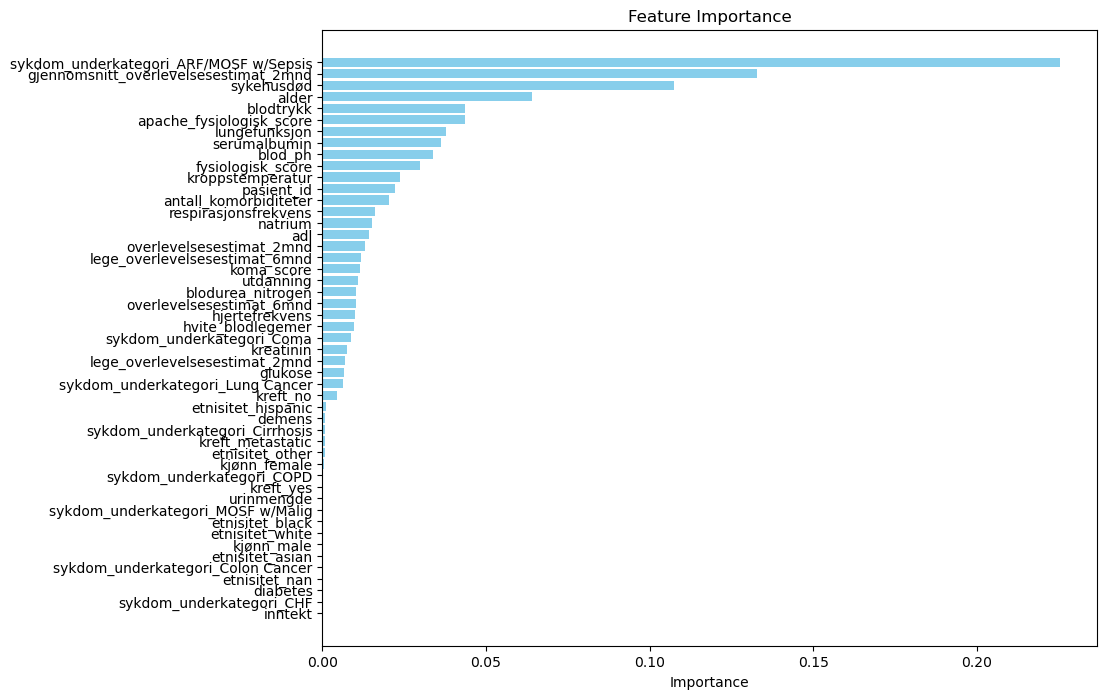

                                   Feature  Importance
24                                 inntekt    0.000000
12                sykdom_underkategori_CHF    0.000000
7                                 diabetes    0.000000
32                           etnisitet_nan    0.000000
15       sykdom_underkategori_Colon Cancer    0.000000
27                         etnisitet_asian    0.000000
26                              kjønn_male    0.000000
31                         etnisitet_white    0.000000
28                         etnisitet_black    0.000020
18       sykdom_underkategori_MOSF w/Malig    0.000100
46                              urinmengde    0.000149
21                               kreft_yes    0.000207
13               sykdom_underkategori_COPD    0.000332
25                            kjønn_female    0.000653
30                         etnisitet_other    0.000668
19                        kreft_metastatic    0.000685
14          sykdom_underkategori_Cirrhosis    0.000758
8         

In [387]:
importances = best_model.feature_importances_

# Kombiner med kolonnenavnene
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})

# Sorter etter viktighet
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


# Anta at `feature_importance_df` er DataFrame med kolonnene 'Feature' og 'Importance'
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

print(feature_importance_df)
zero_importance_features = feature_importance_df[feature_importance_df['Importance'] == 0]['Feature'].tolist()
print(zero_importance_features)





## Grid search

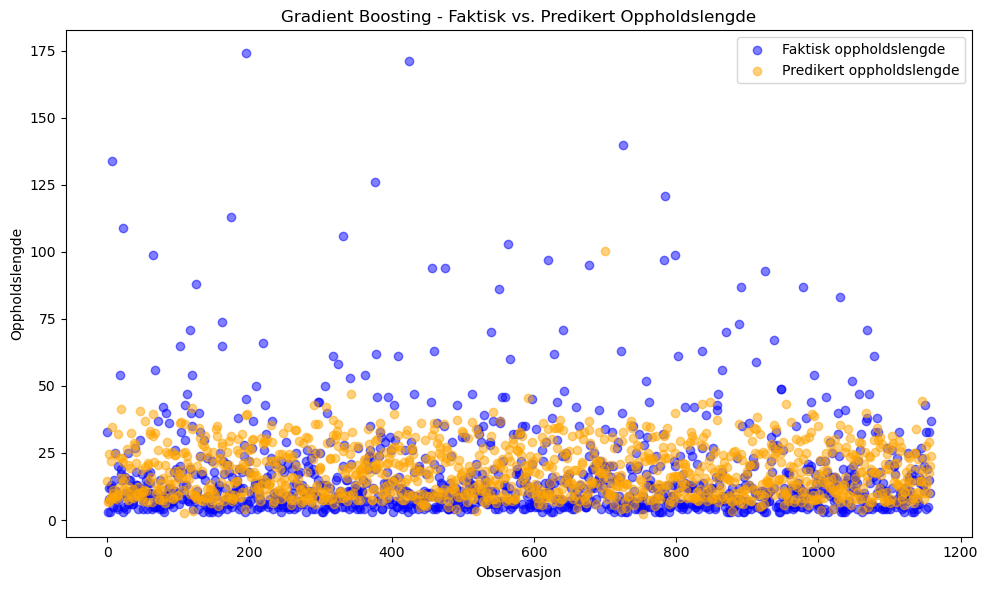

RMSE på valideringssettet: 16.7281


In [390]:


# Anta at y_val er de faktiske verdiene fra valideringssettet
y_val = np.array(y_val)  # Faktiske verdier fra valideringsdata

# Imputer valideringsdata med gjennomsnitt
mean_imputer = SimpleImputer(strategy='mean')
X_val_imputed = mean_imputer.fit_transform(X_val)

# Tren modellen på treningsdata og generer prediksjoner
gbr_model = GradientBoostingRegressor(random_state=42)
X_train_imputed = mean_imputer.fit_transform(X_train)
gbr_model.fit(X_train_imputed, y_train)

# Generer prediksjoner fra modellen
y_val_pred = gbr_model.predict(X_val_imputed)

# Funksjon for å lage en visualisering som viser faktiske vs. predikerte verdier
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Bruk scatter-plot for å vise faktiske og predikerte verdier
ax.scatter(range(len(y_val)), y_val, color='blue', label='Faktisk oppholdslengde', alpha=0.5)
ax.scatter(range(len(y_val_pred)), y_val_pred, color='orange', label='Predikert oppholdslengde', alpha=0.5)

# Legg til tittel og etiketter
ax.set_title("Gradient Boosting - Faktisk vs. Predikert Oppholdslengde")
ax.set_xlabel("Observasjon")
ax.set_ylabel("Oppholdslengde")
ax.legend()

# Vis plottet
plt.tight_layout()
plt.show()

# Valgfritt: Beregn og skriv ut RMSE for valideringssettet
rmse = root_mean_squared_error(y_val, y_val_pred)
print(f"RMSE på valideringssettet: {rmse:.4f}")


## Nettside